### Mandelbrot Trajectory Divergence

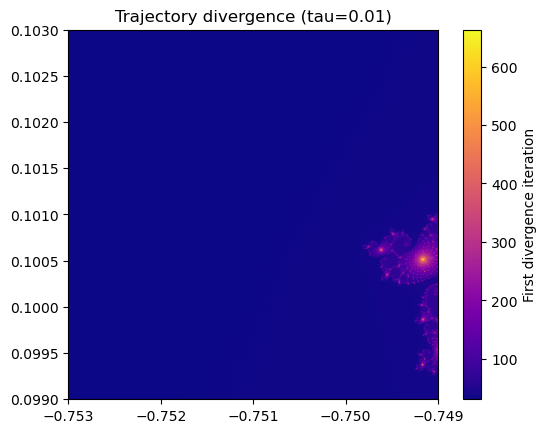

In [11]:
import numpy as np
import matplotlib.pyplot as plt
X_MIN, X_MAX, Y_MIN, Y_MAX = -0.7530, -0.7490, 0.0990, 0.1030
N, MAX_ITER, TAU = 512, 1000, 0.01
x= np.linspace(X_MIN, X_MAX, N)
y= np.linspace(Y_MIN, Y_MAX, N)

C64 = (x[np.newaxis, :] + 1j * y[:, np.newaxis]).astype(np.complex128)
z64 = np.zeros_like(C64)
C32 = C64.astype(np.complex64)
z32 = np.zeros_like(C32)

diverge = np.full((N, N), MAX_ITER, dtype=np.int32)
active  = np.ones((N, N), dtype=bool)

for k in range(MAX_ITER):
    if not active.any(): break
    z64[active] = z64[active]**2 + C64[active]
    z32[active] = z32[active]**2 + C32[active]
    diff = np.abs(z32.astype(np.complex128) - z64)
    newly = active & (diff > TAU)
    diverge[newly] = k
    active[newly] = False

plt.imshow(diverge, cmap='plasma', origin='lower', extent=[X_MIN, X_MAX, Y_MIN, Y_MAX])
plt.colorbar(label='First divergence iteration')
plt.title(f'Trajectory divergence (tau={TAU})')
plt.show()

### Mandelbrot Sensitivity Map

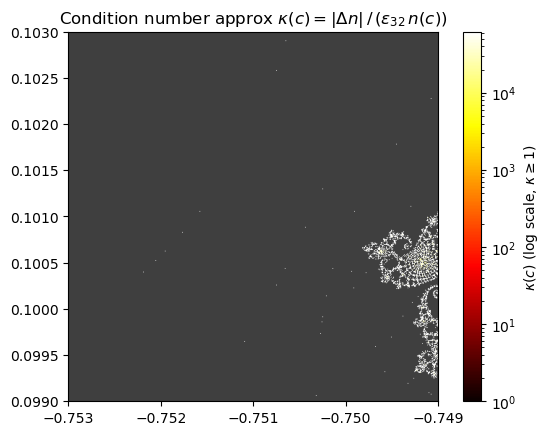

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
N, MAX_ITER = 512, 1000
x = np.linspace(-0.7530, -0.7490, N)
y = np.linspace( 0.0990, 0.1030, N)
C = (x[np.newaxis, :] + 1j * y[:, np.newaxis]).astype(np.complex128)
eps32 = float(np.finfo(np.float32).eps)
delta = np.maximum(eps32 * np.abs(C), 1e-10)

def escape_count(C, max_iter):
    z = np.zeros_like(C); cnt = np.full(C.shape, max_iter, dtype=np.int32)
    esc = np.zeros(C.shape, dtype=bool)
    for k in range(max_iter):
        z[~esc] = z[~esc]**2 + C[~esc]
        newly = ~esc & (np.abs(z) > 2.0)
        cnt[newly] = k; esc[newly] = True
    return cnt

n_base = escape_count(C, MAX_ITER).astype(float)
n_perturb = escape_count(C + delta, MAX_ITER).astype(float)
dn = np.abs(n_base - n_perturb)
kappa = np.where(n_base > 0, dn / (eps32 * n_base), np.nan)
cmap_k = plt.cm.hot.copy(); cmap_k.set_bad('0.25')
vmax = np.nanpercentile(kappa, 99)

plt.imshow(kappa, cmap=cmap_k, origin='lower',
           extent=[-0.7530, -0.7490, 0.0990, 0.1030],
           norm=LogNorm(vmin=1, vmax=vmax))
plt.colorbar(label=r'$\kappa(c)$ (log scale, $\kappa \geq 1$)')
plt.title(r'Condition number approx $\kappa(c) = |\Delta n|\,/\,(\varepsilon_{32}\,n(c))$')
plt.show()